<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png", width=550, height=300></p>

<h3 style="text-align: center;"><b>Физтех-Школа Прикладной математики и информатики (ФПМИ) МФТИ</b></h3>

---

<h2 style="text-align: center;"><b>Transfer Learning</b></h3>

Как Вы уже знаете в современных задачах обработки изображений, будь то задача обнаружения объектов, задача распознавания образов, задача (семантической) сегментации, задача классификации изображений и другие, всё чаще используют **свёрточные нейросети** (*Convolutional Neural Networks*, *CNN*).

Они показывают очень хорошие результаты, за ними стоит как [математический аппарат](https://stats.stackexchange.com/questions/269854/are-there-mathematical-reasons-for-convolution-in-neural-networks-beyond-expedie), так и эвристики, полученные опытным путём.

В данном задании Вам предстоит познакомиться с архитектурами *AlexNet*, *VGG* и *Inception* и для каждой из этих моделей использовать технику **Transfer Learning**.  

* **Transfer Learning** - это процесс дообучения на **новых данных** какой-либо нейросети, уже обученной до этого на других данных, обычно на каком-нибудь хорошем, большом (миллионы картинок) датасете (например, [ImageNet](http://www.image-net.org/) ~ 14 млн картинок).

<h2 style="text-align: center;"><b>AlexNet</b></h2>

**AlexNet** - нейронная сеть, которая победила в ILSVRC (соревнование по классификации картинок из ImageNet) в 2012 году и стала основой для многих других архитектур. Впервые она была представлена в статье  “ImageNet Classification with Deep Convolutional Neural Networks”, над которой работал Джоффри Хинтон - человек, которого многие называют отцом современного computer vision.

Архитектура описана на картинке ниже

<img src="https://www.learnopencv.com/wp-content/uploads/2018/05/AlexNet-1.png">

**AlexNet** состоит из 5 **сверточных** слоев, 3 **MaxPool** слоев и 2 **FullyConnected** слоев в конце. Обратите внимание, что в последнем пулинг слое окна, из которых берется максимум, пересекаются за счет того, что *stride*=2. Это изменение по сравнению с традиционным пулингом помогло снизить ошибку на 0.4%.

По сути **AlexNet** это самая базовая архитектура для сверточной сети после LeNet, которую мы уже писали на предыдущем занятии.

<h2 style="text-align: center;"><b>VGG</b></h3>

Один **сверточный** слой с фильтром 5$\times$5 можно заменить двумя подряд идущими слоями с фильтрами размером 3$\times$3, так как **воспринимаемая область** картинки у них будет одинаковой. При этом уменьшиться количество параметров, поэтому такую сеть будет легче обучать.

На момент создания VGG люди уже заметили, что чем больше слоев в нейросети, тем выше ее точность. Заменяя большие фильтры на несколько фильтров 3$\times$3 исследователи получили глубокую нейросеть с меньшим количеством параметров. Архитектура VGG-16 (версии VGG с 16 слоями) представлена на картинке ниже:


<img src="https://cdn-images-1.medium.com/max/1040/1*0Tk4JclhGOCR_uLe6RKvUQ.png">

Когда говорят **VGG**, то чаще всего имеют ввиду **VGG-16** или **VGG-19**. Более глубоких версий **VGG** нет, так как после 19 слоев точность начинает падать.

Чтобы добиться высоких результатов в соревновании при обучении и валидации нейросети использовались дополнительные премы, подробнее о которых можно прочитать в [статье на Medium](https://medium.com/coinmonks/paper-review-of-vggnet-1st-runner-up-of-ilsvlc-2014-image-classification-d02355543a11).


<h2 style="text-align: center;"><b>Inception v1</b></h3>

### Рассмотрим идею, которая подтолкнула исследователей к созданию этой архитектуры.

Площадь, которую занимает классифицируемый объект, может очень сильно отличаться. Пример на картинке ниже:

<img src="https://cdn-images-1.medium.com/max/1040/1*aBdPBGAeta-_AM4aEyqeTQ.jpeg">

* Для извлечения информации с большой площади лучше всего подходят **большие** фильтры, и наоборот для маленьких объектов лучше **маленькие** фильтры.
* Глубокие нейронные сети намного сложнее обучать: в них появляется проблема **затухания градиента** и они **переобучаются**.
Чтобы решить первую проблему исследователи придумали **Incepton** модуль, который применяет фильтры разного размера и затем склеивает полученные каналы. При этом извлекается как информация из больших объектов, так и из маленьких. Простейшая реализация модуля выглядит так:
<img src="https://cdn-images-1.medium.com/max/1040/1*DKjGRDd_lJeUfVlY50ojOA.png">

Реализацию можно сделать более эффективной, если сначала уменьшить количество каналов с помощью **сверточного слоя** 1$\times$1 и лишь затем применить **слой** с фильтрами 5$\times$5. Сокращение вычислений происходит за счет того, что мы сначала **уменьшаем размерность** данных и лишь затем преобразовываем их. Продвинутая реализация:
<img src="https://cdn-images-1.medium.com/max/1040/1*U_McJnp7Fnif-lw9iIC5Bw.png">

Сеть состоит из **корня** (нескольких сверточных слоев) и **Inception** модулей идущих за ним. Оранжевым прямоугольников выделен корень, а фиолетовыми - **вспомогательные классификаторы**. Именно они помогают бороться со второй проблемой, которую мы упомянули ранее. Наша функция потерь - взвешенная сумма **LogLoss** на двух **вспомогательных классификаторах** и **основном** в конце нейронной сети.
<img src="https://cdn-images-1.medium.com/max/1040/1*uW81y16b-ptBDV8SIT1beQ.png">

После Inception v1 были представлены 2, 3 и 4 версии, пррочитать о которых вы можете  в [статье на Medium](https://towardsdatascience.com/a-simple-guide-to-the-versions-of-the-inception-network-7fc52b863202).

Однако сейчас научились иначе бороться с затуханием градиентов с помощью **residual conncection**. Это позволило увеличить число слоев в нейронной сети.

![](https://i.imgur.com/XwcnU5x.png)

<h2 style="text-align: center;"><b>Transfer Learning</b></h3>

Теперь мы перейдем к тому, как можно использовать уже обученные нейросети, чтобы ускорить свою работу.

Давайте вспомним общую архитектуру CNN:

<img src="https://drive.google.com/uc?id=14pApKqQjnmWMXazY0HHjREn9rI9uwCQg">

С помощью операций *свёртки (convolution)* и *пулинга (pooling)* всё, что расположено до этапа *classification*, по сути **извлекает признаки из объектов, подающихся на вход** (картинок, в данном случае). То есть вместо того, чтобы самим пытаться как-то описать картинки для хорошей работы классификатора, мы предоставляем заняться этим нейросети (обучая её методом обратного распространения ошибки ([лекция 4](https://www.youtube.com/watch?v=HZDOhHAg5_g))).

**Вопрос (творческий):**  А какие признаки для картинок приходят Вам в голову? (считать, что картинки цветные (3 канала), все одинакового размера)

**Ответ:** <Ваши мысли>

Представим теперь, что eсть свой набор данных, и Вы хотите научить сеть классифицировать объекты из Вашей выборки.  


Надеемся, что теперь Вам стало понятнее, как обучать крутые сети на новых данных.

<h2 style="text-align: center;"><b>Переходим к практике</b></h3>

<p style="text-align: center;"><i>(основано на http://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)</i></p>

Мы будем пользоваться библиотекой PyTorch. Если Вы её ещё не установили, то вот [инструкция на Wiki по установке PyTorch](https://github.com/deepmipt/dlschl/wiki/%D0%98%D0%BD%D1%81%D1%82%D1%80%D1%83%D0%BA%D1%86%D0%B8%D1%8F-%D0%BF%D0%BE-%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5-PyTorch).

In [1]:
!pip install pip==21

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [1]:
!pip install catalyst==21.5

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import time
import os

### В чём состоит задание

Вам предстоит попробовать использовать  типа архитектур свёрточных нейросетей - **AlexNet (сделано за Вас в примере), VGG16, Inception_v3** - как *Feature Extractor*, с помощью *Fine Tuning* и *"из коробки"*.

**Для каждого пункта нужно:**
- вывести график loss'а на обучающей и на валидационной выборке
- вывести качество модели (accuracy)

### Данные  

В данном задании используются сети (из библиотеки **torchvision**), предобученные на датасете ImageNet.  
В качестве новых данных будет датасет Меравьи vs Пчёлы, Вам нужно скачать его отсюда: **[Муравьи vs Пчёлы](https://download.pytorch.org/tutorial/hymenoptera_data.zip)**, *являющийся частью датасета ImageNet*. В нём 400 картинок, ~250 обучение и ~150 валидация (тест).

### Функции для отрисовки и обучения модели:

* Загрузим данные:

In [3]:
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip hymenoptera_data.zip

--2025-06-13 12:41:16--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 18.239.69.129, 18.239.69.40, 18.239.69.7, ...
Connecting to download.pytorch.org (download.pytorch.org)|18.239.69.129|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip.1’

hymenoptera_data.zi 100%[===================>]  45.10M  --.-KB/s    in 0.1s    

2025-06-13 12:41:16 (304 MB/s) - ‘hymenoptera_data.zip.1’ saved [47286322/47286322]

Archive:  hymenoptera_data.zip
replace hymenoptera_data/train/ants/0013035.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace hymenoptera_data/train/ants/1030023514_aad5c608f9.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [9]:
# Преобразование обучающих данных для расширения обучающей выборки и её нормализация
# Для валидационной (тестовой) выборки только нормализация
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(244),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(244),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
# папка с данными. Если запускаете в колабе, нужно скопировать данные к себе в директорию и примонтировать диск. Если запускаете локально -- просто скачайте данные
data_dir = './hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
# специальный класс для загрузки данных в виде батчей

train_dataloader = torch.utils.data.DataLoader(
    image_datasets["train"], batch_size=32,
    shuffle=True
)
val_dataloader = torch.utils.data.DataLoader(
    image_datasets["val"], batch_size=128
)

loaders = {
    "train": train_dataloader,
    "valid": val_dataloader
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

Размеры обучающей и валидационной выборок:

In [10]:
print(dataset_sizes)

{'train': 244, 'val': 153}


['ants', 'bees']

**Вопрос (на понимание кода выше):**  
1. В DataLoader() выше стоит "shuffle=True". Для чего это нужно?
2. Сколько картинок будет в каждом батче?

**Ответ:** <Ваш ответ>

* Посмотрим на картинки из датасета:

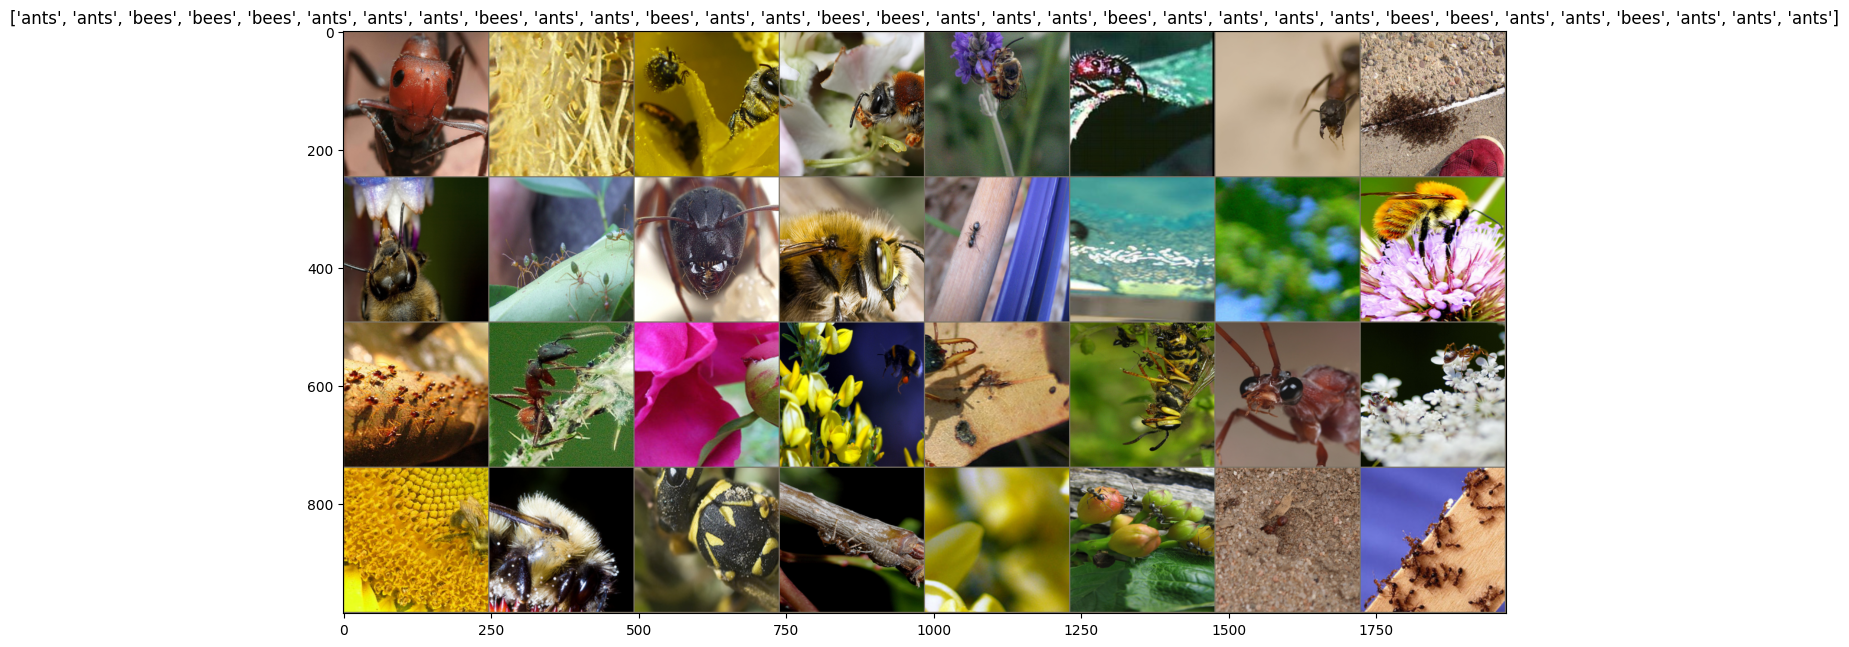

In [11]:
from matplotlib import pyplot as plt

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(15, 12))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


# Получим 1 батч (картнки-метки) из обучающей выборки
inputs, classes = next(iter(loaders['train']))

# Расположим картинки рядом
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [12]:
image_datasets["train"][0]

(tensor([[[-0.7479, -0.7308, -0.7479,  ..., -0.7650, -0.7479, -0.7479],
          [-0.7479, -0.7308, -0.7308,  ..., -0.7822, -0.7822, -0.7479],
          [-0.7479, -0.7308, -0.7308,  ..., -0.8164, -0.8164, -0.7479],
          ...,
          [-1.5185, -1.5357, -1.5870,  ..., -0.6109, -0.6452, -0.6452],
          [-1.5185, -1.5528, -1.6042,  ..., -0.6109, -0.6281, -0.6452],
          [-1.5185, -1.5699, -1.6042,  ..., -0.6109, -0.6109, -0.6452]],
 
         [[ 0.5903,  0.6254,  0.6078,  ...,  0.5903,  0.6078,  0.5553],
          [ 0.5903,  0.6254,  0.6254,  ...,  0.5728,  0.5728,  0.5553],
          [ 0.5903,  0.6254,  0.6254,  ...,  0.5378,  0.5378,  0.5553],
          ...,
          [-1.5105, -1.4930, -1.5105,  ...,  0.6954,  0.6604,  0.6604],
          [-1.4755, -1.4755, -1.5105,  ...,  0.6954,  0.6779,  0.6604],
          [-1.4055, -1.4405, -1.4755,  ...,  0.6954,  0.6954,  0.6604]],
 
         [[ 2.2914,  2.2740,  2.2566,  ...,  2.2391,  2.2566,  2.2566],
          [ 2.2914,  2.2740,

### Обучение моделей

Следующая функция будет использоваться для обучения модели. Аргументы:  
* model $-$ нейросеть
* loss $-$ оптимизируемая функция (criterion, cost function, objective)
* optimizer $-$ оптимизационный алгоритм
* scheduler $-$ политика изменения learning_rate
* num_epochs $-$ количество итераций обучения

In [13]:
from catalyst import dl, metrics

class ImgRunner(dl.Runner):

    def predict_batch(self, batch):
        # model inference step
        return self.model(batch[0].to(self.device).view(batch[0].size(0), -1))

    def handle_batch(self, batch):
        # model train/valid step
        x, y = batch
        self.input = {"targets": y}
        y_hat = self.model(x)
        self.output = {"logits": y_hat}

AttributeError: module 'collections' has no attribute 'MutableMapping'

### Задание

Для каждой из следующих нейросетей:
* **AlexNet** (уже сделано в примере)
* **VGG16**
* **Inception_v3**

Напишите код и выведите результат (график лосса, accuracy и вывод примера классификации картинок с визализацией (с помощью функции `vizualize_model()`)) для трёх способов:
* Использование готовой нейросети **"из коробки"**
* Использование нейросети как **Feature Extractor**
* **Fine Tuning** нейросети

Для каждого пункта нужно:
* сделать с сетью то, что нужно в пункте ("из коробки", FE или FT)
* вывести график loss'а на обучающей и на валидационной выборке
* вывести качество модели (accuracy) на валидационной (тестовой) выборке
* (по желанию) использовать функцию visualize_model()

### AlexNet

*ПРИМЕЧАНИЕ: Здесь не выведены графики loss'а и не использована visualize_model(). От Вас это ожидается.*

Загрузка модели:

In [164]:
model = models.alexnet(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Посмотрим, что внутри:

In [165]:
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Видим, что на вход классификатору (classifier) подаётся *9216 признаков*. Это и будет размер входа для нашего нового классификатора.

* **Fine Tuning** способ

Сконфигурируем - изменим FC-слой и зададим *cost function* и *оптимизирующий алгоритм*:

(*по умолчанию backpropagation распространяется на все слои, поэтому здесь мы только заменяем FC-слой на свой классификатор*)

In [151]:
!rm -rf logs

In [166]:
# num_features -- это размерность вектора фич, поступающего на вход FC-слою
from torch.optim.lr_scheduler import StepLR
num_features = 4096
# Заменяем Fully-Connected слой на наш линейный классификатор
model.classifier[6] = nn.Linear(num_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
lr_scheduler = scheduler = StepLR(optimizer, step_size=2, gamma=0.5)



In [167]:
import matplotlib.pyplot as plt


def train_epoch(model, dataloader, optimizer, lr_scheduler):
  sum_loss = 0
  sum_correct = 0
  model.train()
  for batch, y in dataloader:
    batch, y = batch.to(device), y.to(device)
    preds = model(batch)
    sum_correct += (y == preds.argmax(-1)).sum()
    optimizer.zero_grad()
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()
    sum_loss += loss
  #lr_scheduler.step()

  return {'loss': (sum_loss).item(), 'acc': (sum_correct/len(image_datasets['train'])).item()}




def eval(model, dataloader):
  sum_correct = 0
  sum_loss = 0
  model.eval()
  for batch, y in dataloader:

    batch, y = batch.to(device), y.to(device)
    preds = model(batch)
    sum_correct += (y == preds.argmax(-1)).sum()
    loss = criterion(preds, y)
    sum_loss += loss

  return {'loss': (sum_loss).item(), 'acc': (sum_correct/len(image_datasets['val'])).item()}

val_losses = []
train_losses = []
val_accs = []
train_accs = []

for i in range(10):
  print(f'---epoch #{i+1}---')
  train_loss, train_acc = train_epoch(model, train_dataloader, optimizer, lr_scheduler).values()
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  print(f'train_loss: {train_loss}, train_acc: {train_acc}')
  test_loss, test_acc = eval(model, val_dataloader).values()
  val_losses.append(test_loss)
  val_accs.append(test_acc)
  print(f'test_loss: {test_loss}, train_acc: {test_acc}')


---epoch #1---
train_loss: 4.140487194061279, train_acc: 0.7254098057746887
test_loss: 0.7437440156936646, train_acc: 0.9084967374801636
---epoch #2---
train_loss: 1.8648110628128052, train_acc: 0.9016392827033997
test_loss: 0.847424328327179, train_acc: 0.9215686321258545
---epoch #3---
train_loss: 1.6187677383422852, train_acc: 0.9221311211585999
test_loss: 0.7741868495941162, train_acc: 0.9084967374801636
---epoch #4---
train_loss: 1.498620867729187, train_acc: 0.930327832698822
test_loss: 1.1286839246749878, train_acc: 0.8954248428344727
---epoch #5---
train_loss: 1.495876669883728, train_acc: 0.9221311211585999
test_loss: 0.7868618965148926, train_acc: 0.9019607901573181
---epoch #6---
train_loss: 1.213864803314209, train_acc: 0.9590163230895996
test_loss: 0.5691016912460327, train_acc: 0.8496732115745544
---epoch #7---
train_loss: 1.0668885707855225, train_acc: 0.9508196115493774
test_loss: 1.035796046257019, train_acc: 0.9019607901573181
---epoch #8---
train_loss: 1.151566386222

In [145]:
train_losses

[4.404605865478516,
 2.2422382831573486,
 1.762343168258667,
 1.3504348993301392,
 1.2002722024917603,
 1.473947525024414,
 0.6433293223381042,
 1.0236093997955322,
 0.5678226947784424,
 0.950065016746521]

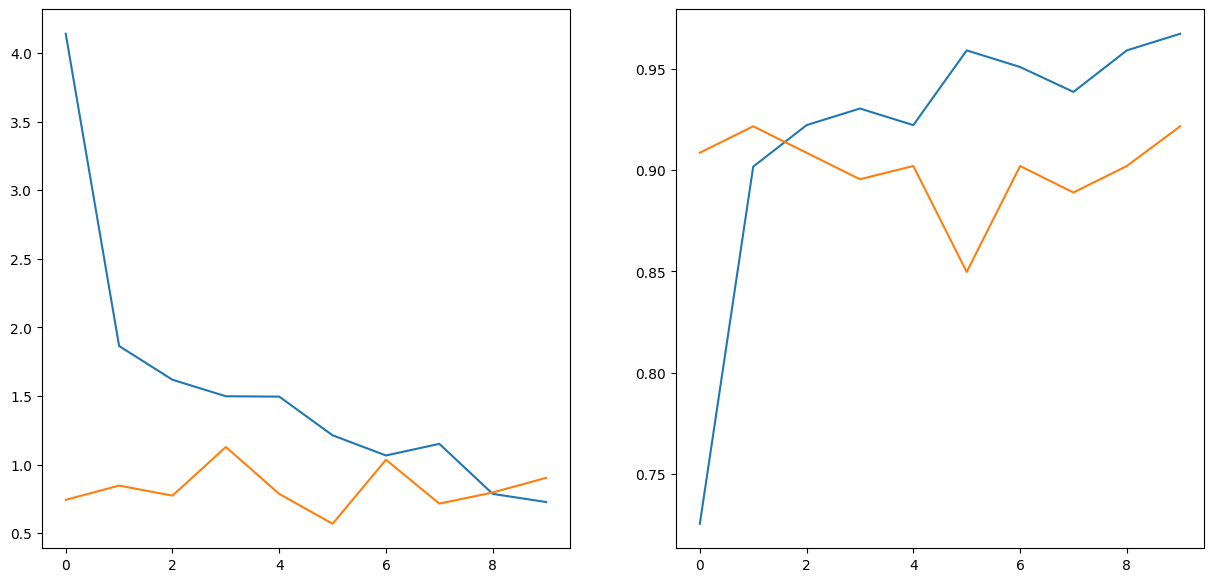

In [168]:
fig, axes = plt.subplots(1,2, figsize = (15,7))
axes[0].plot([i for i in range(10)], train_losses)
axes[0].plot([i for i in range(10)], val_losses)

axes[1].plot([i for i in range(10)], train_accs)
axes[1].plot([i for i in range(10)], val_accs)

In [81]:
model(image_datasets['train'][0][0].to(device).unsqueeze(0))

tensor([[ 5.0602, -2.6705]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [157]:
for i in range(10):
  img = len(image_datasets['val'])


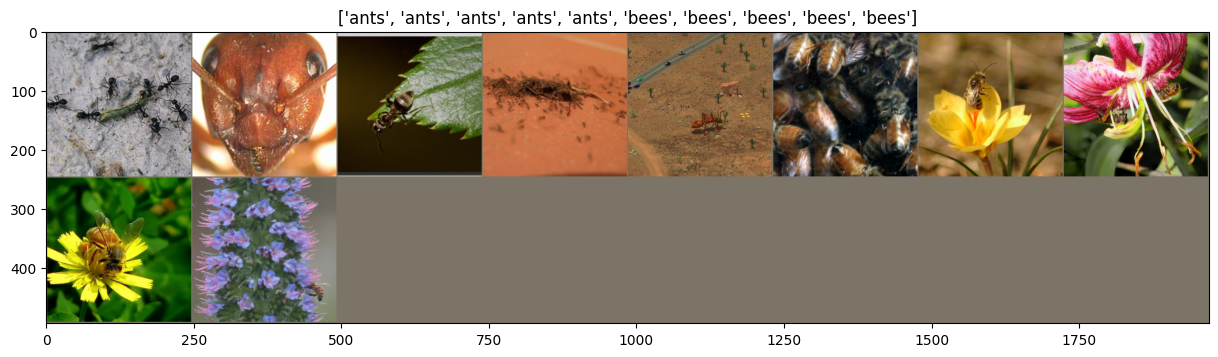

In [94]:
inputs, classes = next(iter(val_dataloader))

# Расположим картинки рядом
out = torchvision.utils.make_grid(inputs[65:75])

preds = model(inputs.to(device))
labels = [class_names[i] for i in preds.argmax(-1)][65:75]

imshow(out, title=labels)

* **Feature Extractor** способ:

In [191]:
model_extractor = models.alexnet(pretrained=True)

Помним, что по-умолчанию все слои нейросети обучаются заново:

In [192]:
for param in model_extractor.parameters():
    print(param.requires_grad)
    break

True


Сделаем так, чтобы на них *не распространялся backpropagation* (заморозим их), и подменим классификатор (ведь старый уже с весами для ImageNet'а).

In [193]:
# замораживаем параметры (веса)
for param in model_extractor.parameters():
    param.requires_grad = False

# num_features -- это размерность вектора фич, поступающего на вход FC-слою
num_features = 4096
# Заменяем Fully-Connected слой на наш линейный классификатор
model_extractor.classifier[6] = nn.Linear(num_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_extractor.to(device)

# Обучаем только классификатор
#optimizer = optim.Adam(model_extractor.classifier[6].parameters(), lr=1e-4)
optimizer = optim.Adam(model_extractor.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
lr_scheduler = scheduler = StepLR(optimizer, step_size=2, gamma=0.5)


In [194]:
def train_epoch(model, dataloader, optimizer, lr_scheduler):
  sum_loss = 0
  sum_correct = 0
  model.train()
  for batch, y in dataloader:
    batch, y = batch.to(device), y.to(device)
    preds = model(batch)
    sum_correct += (y == preds.argmax(-1)).sum()
    optimizer.zero_grad()
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()
    sum_loss += loss
  lr_scheduler.step()

  return {'loss': (sum_loss).item(), 'acc': (sum_correct/len(image_datasets['train'])).item()}




def eval(model, dataloader):
  sum_correct = 0
  sum_loss = 0
  model.eval()
  for batch, y in dataloader:

    batch, y = batch.to(device), y.to(device)
    preds = model(batch)
    sum_correct += (y == preds.argmax(-1)).sum()
    loss = criterion(preds, y)
    sum_loss += loss

  return {'loss': (sum_loss).item(), 'acc': (sum_correct/len(image_datasets['val'])).item()}

val_losses = []
train_losses = []
val_accs = []
train_accs = []

for i in range(10):
  print(f'---epoch #{i+1}---')
  train_loss, train_acc = train_epoch(model_extractor, train_dataloader, optimizer, lr_scheduler).values()
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  print(f'train_loss: {train_loss}, train_acc: {train_acc}')
  test_loss, test_acc = eval(model_extractor, val_dataloader).values()
  val_losses.append(test_loss)
  val_accs.append(test_acc)
  print(f'test_loss: {test_loss}, train_acc: {test_acc}')

---epoch #1---
train_loss: 5.468603610992432, train_acc: 0.6065573692321777
test_loss: 1.155722737312317, train_acc: 0.6928104758262634
---epoch #2---
train_loss: 4.44534969329834, train_acc: 0.7336065173149109
test_loss: 0.9256182909011841, train_acc: 0.8104575276374817
---epoch #3---
train_loss: 3.7929370403289795, train_acc: 0.799180269241333
test_loss: 0.855918824672699, train_acc: 0.8366013169288635
---epoch #4---
train_loss: 3.5305378437042236, train_acc: 0.7909835577011108
test_loss: 0.8118178844451904, train_acc: 0.843137264251709
---epoch #5---
train_loss: 3.250295400619507, train_acc: 0.8278688192367554
test_loss: 0.8015604019165039, train_acc: 0.8562091588973999
---epoch #6---
train_loss: 3.18440580368042, train_acc: 0.8442622423171997
test_loss: 0.7848144769668579, train_acc: 0.8562091588973999
---epoch #7---
train_loss: 3.131786584854126, train_acc: 0.8360655307769775
test_loss: 0.7769519090652466, train_acc: 0.8692810535430908
---epoch #8---
train_loss: 2.9737424850463867

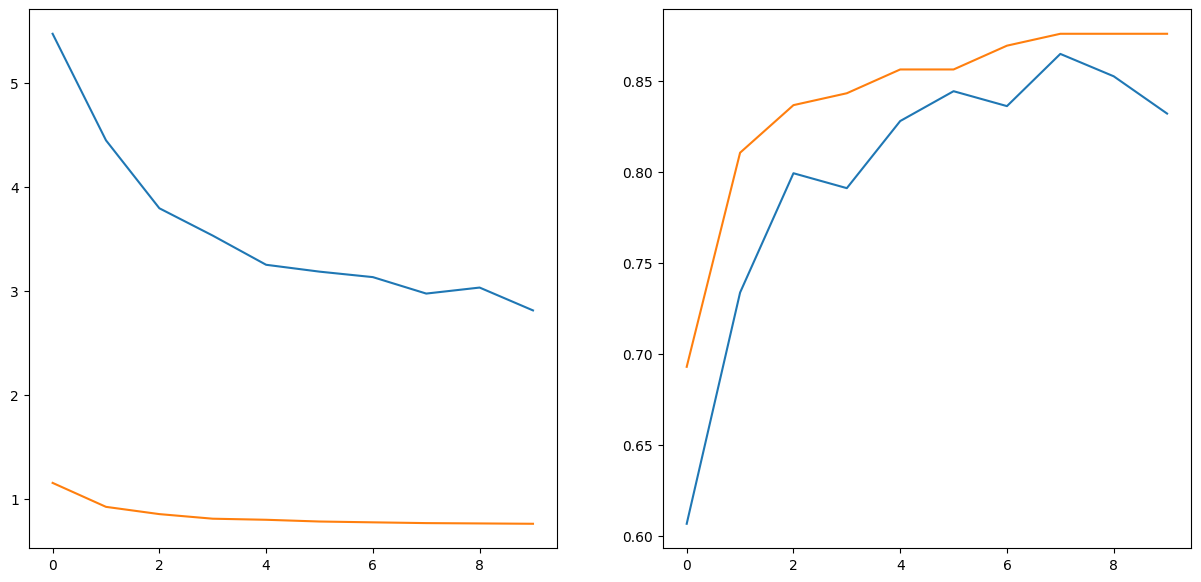

In [195]:
fig, axes = plt.subplots(1,2, figsize = (15,7))
axes[0].plot([i for i in range(10)], train_losses)
axes[0].plot([i for i in range(10)], val_losses)

axes[1].plot([i for i in range(10)], train_accs)
axes[1].plot([i for i in range(10)], val_accs)

* **Смешанный** способ:
Мы будем обучать не только последний **fully connected** слой, но и несколько предпоследних

In [196]:
model_mixed = models.alexnet(pretrained=True)

In [197]:
model_mixed

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [198]:
from itertools import chain

layers_to_unfreeze = 5

# Выключаем подсчет градиентов для слоев, которые не будем обучать
for param in model_mixed.features[:-layers_to_unfreeze].parameters():
    param.requires_grad = False

# num_features -- это размерность вектора фич, поступающего на вход FC-слою
num_features = 4096
# Заменяем Fully-Connected слой на наш линейный классификатор
model_mixed.classifier[6] = nn.Linear(num_features, 2)
model_mixed.to(device)
# Обучаем последние layers_to_unfreeze слоев из сверточной части и fully connected слой
# parameters() возвращает просто список тензоров парамтеров, поэтому два таких списка можно сложить
optimizer = torch.optim.Adam( model_mixed.parameters(),lr=1e-4)
criterion = nn.CrossEntropyLoss()
lr_scheduler = StepLR(optimizer, step_size=2, gamma=0.5)

In [199]:
val_losses = []
train_losses = []
val_accs = []
train_accs = []

for i in range(10):
  print(f'---epoch #{i+1}---')
  train_loss, train_acc = train_epoch(model_mixed, train_dataloader, optimizer, lr_scheduler).values()
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  print(f'train_loss: {train_loss}, train_acc: {train_acc}')
  test_loss, test_acc = eval(model_mixed, val_dataloader).values()
  val_losses.append(test_loss)
  val_accs.append(test_acc)
  print(f'test_loss: {test_loss}, train_acc: {test_acc}')

---epoch #1---
train_loss: 3.8502392768859863, train_acc: 0.7418032288551331
test_loss: 0.9650133848190308, train_acc: 0.8758170008659363
---epoch #2---
train_loss: 1.7474243640899658, train_acc: 0.9180327653884888
test_loss: 0.7084940671920776, train_acc: 0.8823529481887817
---epoch #3---
train_loss: 1.606978178024292, train_acc: 0.8934425711631775
test_loss: 1.1495534181594849, train_acc: 0.8888888955116272
---epoch #4---
train_loss: 1.4762365818023682, train_acc: 0.9262294769287109
test_loss: 0.9331982135772705, train_acc: 0.8954248428344727
---epoch #5---
train_loss: 1.2272998094558716, train_acc: 0.930327832698822
test_loss: 0.798625111579895, train_acc: 0.9019607901573181
---epoch #6---
train_loss: 1.2897725105285645, train_acc: 0.9344261884689331
test_loss: 0.8106955885887146, train_acc: 0.9019607901573181
---epoch #7---
train_loss: 0.9131466746330261, train_acc: 0.9590163230895996
test_loss: 0.8837530612945557, train_acc: 0.915032684803009
---epoch #8---
train_loss: 1.093231081

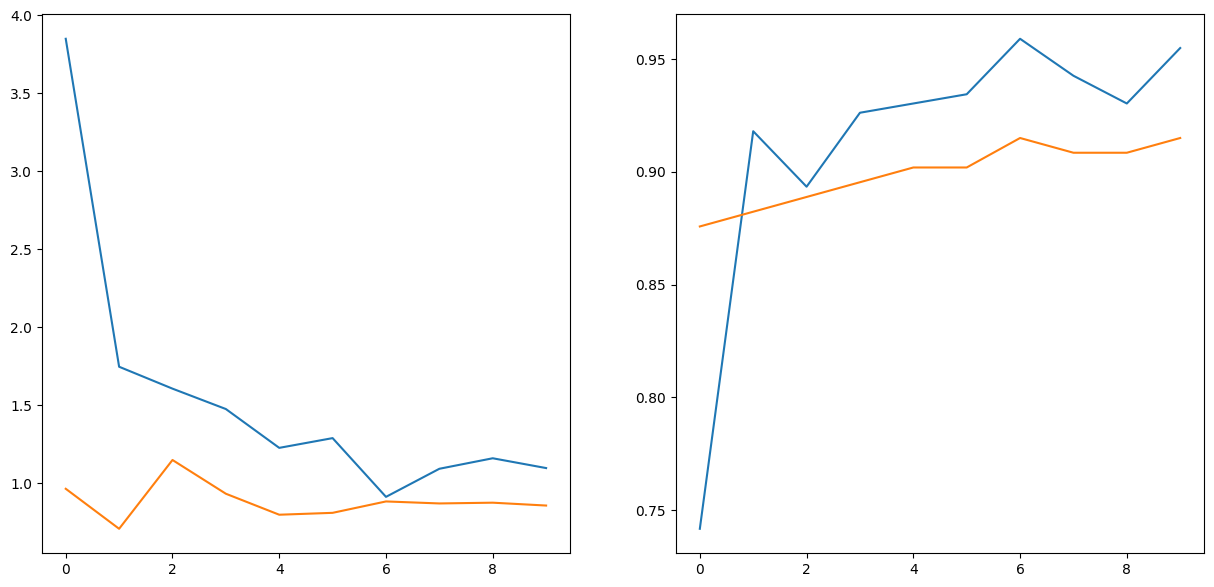

In [200]:
fig, axes = plt.subplots(1,2, figsize = (15,7))
axes[0].plot([i for i in range(10)], train_losses)
axes[0].plot([i for i in range(10)], val_losses)

axes[1].plot([i for i in range(10)], train_accs)
axes[1].plot([i for i in range(10)], val_accs)

**Вопрос 1 (важный):** С чем связано повышение качества если мы перестаем учить всю сеть? (Подсказка: посмотрите на датасет и на то, как он согласуется с 4-мя ситуациями, описанными выше)

**Ответ (важный):** <Ваш ответ>

**Вопрос 2**: Почему разморозка последних слоев не дает прироста к точности, хотя разморозить несколько послдних слоев обычно хорошеее решение для классификации похожего датасета? (Вопрос на внимательность)

**Ответ:** <Ваш ответ>

### Бонус

Существует еще один интересный способ. Мы не хотим, чтобы ядра в свертках сильно менялись во время обучения, а еще мы знаем, что чем меньше lr, тем меньше изменения. Давайте уменьшим lr на feature extractor-е! Разберемся как это сделать...

In [201]:
model_mixed_lr = models.alexnet(pretrained=True)

# num_features -- это размерность вектора фич, поступающего на вход FC-слою
num_features = 4096
# Заменяем Fully-Connected слой на наш линейный классификатор
model_mixed_lr.classifier[6] = nn.Linear(num_features, 2)
model_mixed_lr.to(device)
# Обучаем последние layers_to_unfreeze слоев из сверточной части и fully connected слой
# parameters() возвращает просто список тензоров парамтеров, поэтому два таких списка можно сложить
optimizer = torch.optim.Adam(
    (
        {
            "params": model_mixed_lr.features.parameters(),
            "lr": 1e-6,
        },
        {
            "params": model_mixed_lr.classifier.parameters(),
        }
     ),
     lr=1e-4
)

criterion = nn.CrossEntropyLoss()
lr_scheduler = StepLR(optimizer, step_size=2, gamma=0.5)

In [202]:
val_losses = []
train_losses = []
val_accs = []
train_accs = []

for i in range(10):
  print(f'---epoch #{i+1}---')
  train_loss, train_acc = train_epoch(model_mixed_lr, train_dataloader, optimizer, lr_scheduler).values()
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  print(f'train_loss: {train_loss}, train_acc: {train_acc}')
  test_loss, test_acc = eval(model_mixed_lr, val_dataloader).values()
  val_losses.append(test_loss)
  val_accs.append(test_acc)
  print(f'test_loss: {test_loss}, train_acc: {test_acc}')

---epoch #1---
train_loss: 4.401799201965332, train_acc: 0.6844261884689331
test_loss: 0.9359040260314941, train_acc: 0.8562091588973999
---epoch #2---
train_loss: 2.45415997505188, train_acc: 0.8647540211677551
test_loss: 0.5690444111824036, train_acc: 0.8954248428344727
---epoch #3---
train_loss: 1.9454401731491089, train_acc: 0.9057376384735107
test_loss: 0.5780794620513916, train_acc: 0.9019607901573181
---epoch #4---
train_loss: 1.5457121133804321, train_acc: 0.9139343500137329
test_loss: 0.7827889323234558, train_acc: 0.9084967374801636
---epoch #5---
train_loss: 1.6152127981185913, train_acc: 0.8893442153930664
test_loss: 0.7206333875656128, train_acc: 0.915032684803009
---epoch #6---
train_loss: 1.324426293373108, train_acc: 0.9344261884689331
test_loss: 0.6376703381538391, train_acc: 0.9084967374801636
---epoch #7---
train_loss: 1.0485490560531616, train_acc: 0.9467212557792664
test_loss: 0.6144400835037231, train_acc: 0.915032684803009
---epoch #8---
train_loss: 1.37172007560

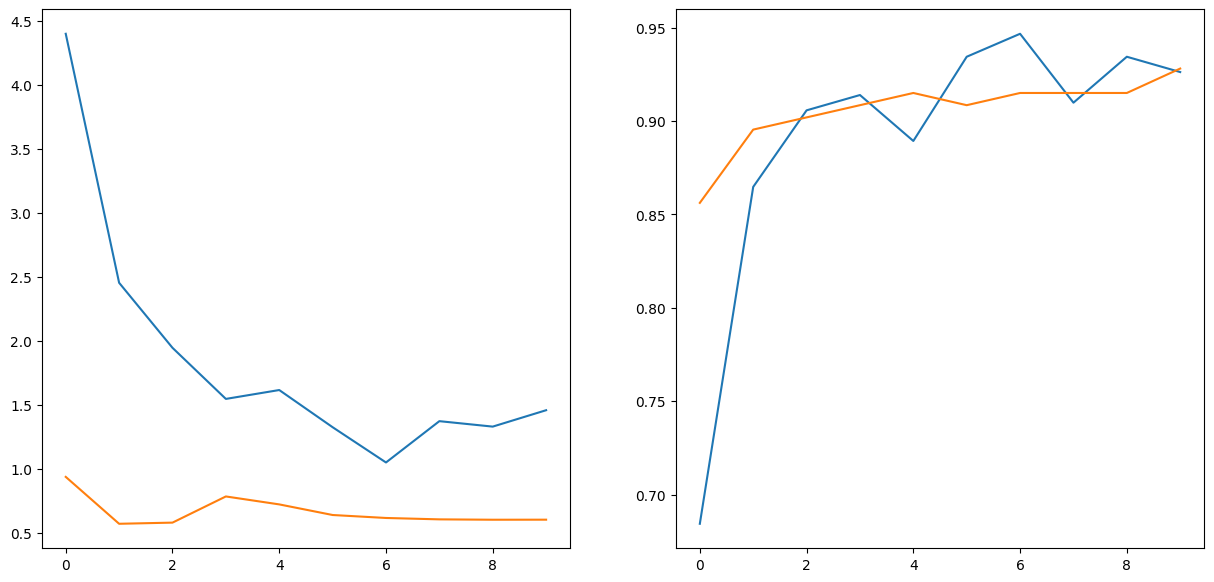

In [203]:
fig, axes = plt.subplots(1,2, figsize = (15,7))
axes[0].plot([i for i in range(10)], train_losses)
axes[0].plot([i for i in range(10)], val_losses)

axes[1].plot([i for i in range(10)], train_accs)
axes[1].plot([i for i in range(10)], val_accs)

### Другие, более современные нейросети

**Вопрос:** Какую стратегию Вы выберете, учитывая размер и специфику нового датасета?

**Ответ:** <Ваш ответ>

### ResNet 18

In [204]:
models.resnet18(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [216]:
# Ваш код здесь
model_extractor = models.resnet18(pretrained=True)

# замораживаем параметры (веса)
for param in model_extractor.parameters():
    param.requires_grad = False

# num_features -- это размерность вектора фич, поступающего на вход FC-слою
num_features = 512
# Заменяем Fully-Connected слой на наш линейный классификатор
model_extractor.fc = nn.Linear(num_features, 2)
model_extractor.to(device)

optimizer = torch.optim.Adam(model_extractor.parameters(),lr=1e-3)
criterion = nn.CrossEntropyLoss()
lr_scheduler = StepLR(optimizer, step_size=2, gamma=1)

In [217]:
val_losses = []
train_losses = []
val_accs = []
train_accs = []

for i in range(10):
  print(f'---epoch #{i+1}---')
  train_loss, train_acc = train_epoch(model_extractor, train_dataloader, optimizer, lr_scheduler).values()
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  print(f'train_loss: {train_loss}, train_acc: {train_acc}')
  test_loss, test_acc = eval(model_extractor, val_dataloader).values()
  val_losses.append(test_loss)
  val_accs.append(test_acc)
  print(f'test_loss: {test_loss}, train_acc: {test_acc}')

---epoch #1---
train_loss: 5.861749172210693, train_acc: 0.5409835577011108
test_loss: 1.0964627265930176, train_acc: 0.6143791079521179
---epoch #2---
train_loss: 4.726375579833984, train_acc: 0.6434425711631775
test_loss: 1.1019706726074219, train_acc: 0.8496732115745544
---epoch #3---
train_loss: 3.8934710025787354, train_acc: 0.7868852019309998
test_loss: 0.9083176851272583, train_acc: 0.9019607901573181
---epoch #4---
train_loss: 3.2929372787475586, train_acc: 0.8360655307769775
test_loss: 0.7889009714126587, train_acc: 0.9346405267715454
---epoch #5---
train_loss: 2.8584237098693848, train_acc: 0.8770491480827332
test_loss: 0.6702593564987183, train_acc: 0.9281045794487
---epoch #6---
train_loss: 2.542149782180786, train_acc: 0.8975409269332886
test_loss: 0.7275028228759766, train_acc: 0.9477124214172363
---epoch #7---
train_loss: 2.5136280059814453, train_acc: 0.8852458596229553
test_loss: 0.5964968204498291, train_acc: 0.9411764740943909
---epoch #8---
train_loss: 2.07143020629

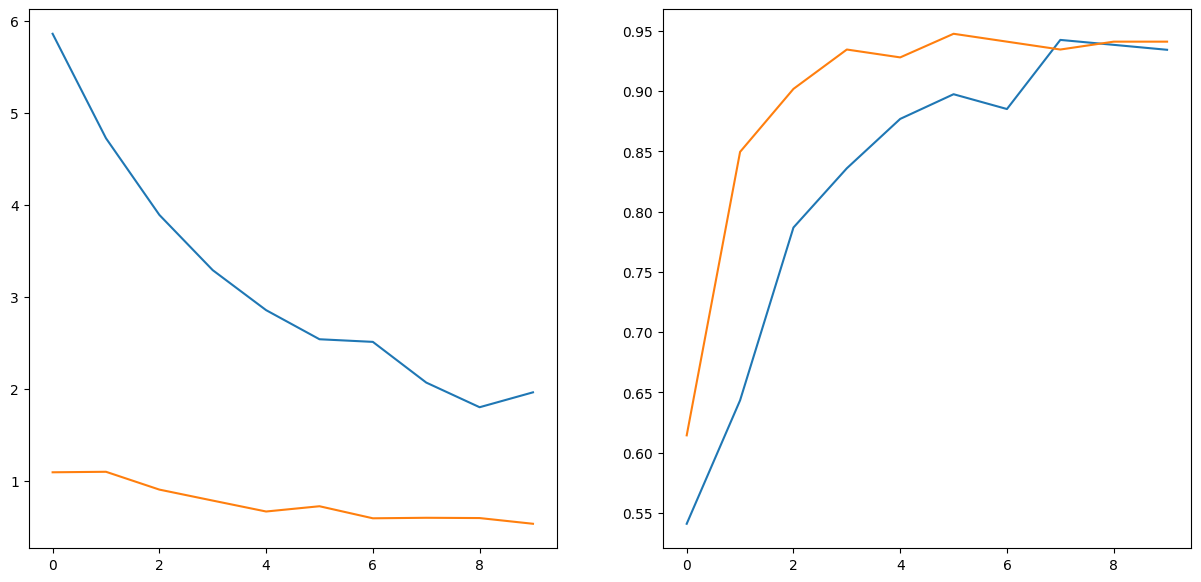

In [218]:
fig, axes = plt.subplots(1,2, figsize = (15,7))
axes[0].plot([i for i in range(10)], train_losses)
axes[0].plot([i for i in range(10)], val_losses)

axes[1].plot([i for i in range(10)], train_accs)
axes[1].plot([i for i in range(10)], val_accs)

In [219]:
# замораживаем параметры (веса)
for param in model_extractor.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model_extractor.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
lr_scheduler = StepLR(optimizer, step_size=2, gamma=1)

for i in range(10):
  print(f'---epoch #{i+1}---')
  train_loss, train_acc = train_epoch(model_extractor, train_dataloader, optimizer, lr_scheduler).values()
  train_losses.append(train_loss)
  train_accs.append(train_acc)
  print(f'train_loss: {train_loss}, train_acc: {train_acc}')
  test_loss, test_acc = eval(model_extractor, val_dataloader).values()
  val_losses.append(test_loss)
  val_accs.append(test_acc)
  print(f'test_loss: {test_loss}, train_acc: {test_acc}')

---epoch #1---
train_loss: 1.9709572792053223, train_acc: 0.9098359942436218
test_loss: 0.4089902639389038, train_acc: 0.9542483687400818
---epoch #2---
train_loss: 0.7806920409202576, train_acc: 0.9713114500045776
test_loss: 0.3935786783695221, train_acc: 0.9542483687400818
---epoch #3---
train_loss: 0.6856823563575745, train_acc: 0.9713114500045776
test_loss: 0.9208964109420776, train_acc: 0.915032684803009
---epoch #4---
train_loss: 0.5367977619171143, train_acc: 0.9795081615447998
test_loss: 0.9721436500549316, train_acc: 0.9084967374801636
---epoch #5---
train_loss: 0.8160127401351929, train_acc: 0.9672130346298218
test_loss: 0.5274854898452759, train_acc: 0.9477124214172363
---epoch #6---
train_loss: 0.37920743227005005, train_acc: 0.9836065173149109
test_loss: 0.428785502910614, train_acc: 0.9477124214172363
---epoch #7---
train_loss: 0.5407832264900208, train_acc: 0.9795081615447998
test_loss: 0.5139853954315186, train_acc: 0.9542483687400818
---epoch #8---
train_loss: 0.383896

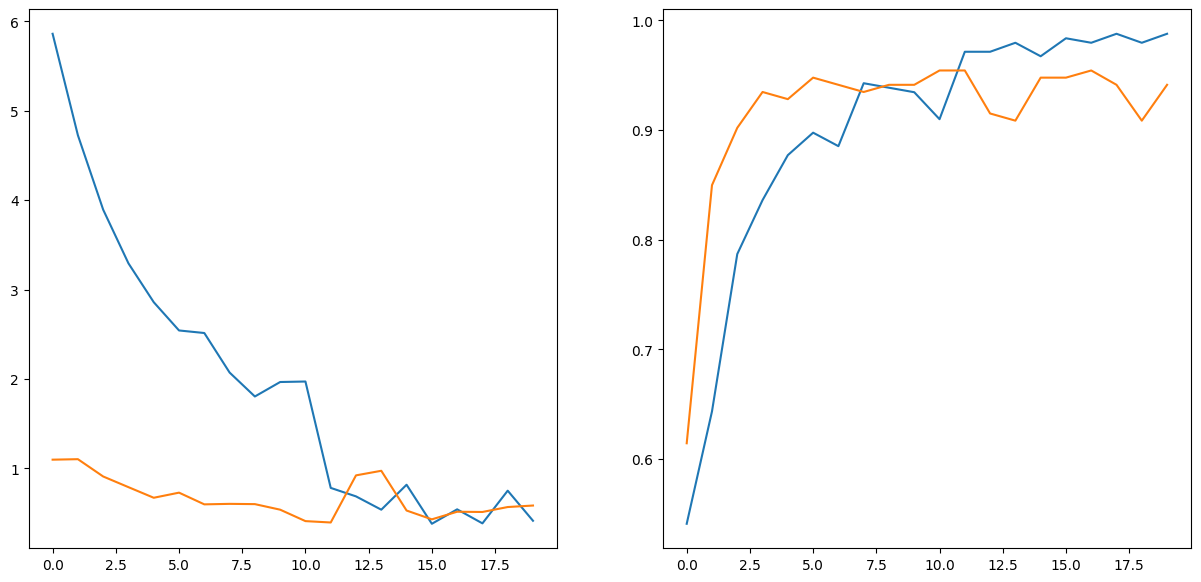

In [221]:
fig, axes = plt.subplots(1,2, figsize = (15,7))
axes[0].plot([i for i in range(20)], train_losses)
axes[0].plot([i for i in range(20)], val_losses)

axes[1].plot([i for i in range(20)], train_accs)
axes[1].plot([i for i in range(20)], val_accs) # Нам тут не помог подход с обучением классификатора и последующем более аккуратным вариантом - дообучением более глубоких слоев на более маленьком lr


<h2 style="text-align: center;"><b>Полезные ссылки</b></h3>

1). *cs231n: http://cs231n.github.io/transfer-learning/*

2). *Туториал на PyTorch Tutorials: https://pytorch.org/tutorials/beginner/transfer_learning_tutorial*

3). *Статья на Medium про TL в PyTorch: https://medium.com/@14prakash/almost-any-image-classification-problem-using-pytorch-i-am-in-love-with-pytorch-26c7aa979ec4*  